In [1]:
# .venvs/python311_conda_3

import os
import sys
module_path = os.path.abspath(os.path.join("../"))
if module_path not in sys.path:
    sys.path.append(module_path)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from epbd_bert.utility.data_utils import get_uniform_peaks_metadata, compute_multi_class_weights
import epbd_bert.utility.pickle_utils as pickle_utils

In [24]:
model_name = "dnabert2_epbd_crossattn_bestmodel"
dnabert2_epbd_crossattn_perf_df = pd.read_csv(f"data/aurocs_auprs/{model_name}_on_test.tsv", sep="\t")
tbinet_perf_df = pd.read_csv(f"data/aurocs_auprs/tbinet_on_test.tsv", sep="\t")

In [25]:
result_df = pd.merge(left=dnabert2_epbd_crossattn_perf_df, right=tbinet_perf_df, on=["index", "cell", "antibody"], how="inner")
result_df

,index,cell,antibody,dnabert2_epbd_crossattn_bestmodel_auroc,dnabert2_epbd_crossattn_bestmodel_aupr,tbinet_auroc,tbinet_aupr
0,wgEncodeAwgTfbsBroadDnd41CtcfUniPk,Dnd41,CTCF,0.96012,0.62702,0.98071,0.70809
1,wgEncodeAwgTfbsBroadDnd41Ezh239875UniPk,Dnd41,EZH2_(39875),0.93142,0.05153,0.95424,0.03926
2,wgEncodeAwgTfbsBroadGm12878CtcfUniPk,GM12878,CTCF,0.95550,0.59429,0.98044,0.68340
3,wgEncodeAwgTfbsBroadGm12878Ezh239875UniPk,GM12878,EZH2_(39875),0.89687,0.03262,0.92033,0.04583
4,wgEncodeAwgTfbsBroadH1hescChd1a301218aUniPk,H1-hESC,CHD1_(A301-218A),0.93621,0.17676,0.94316,0.17773
...,...,...,...,...,...,...,...
685,wgEncodeAwgTfbsUwRptecCtcfUniPk,RPTEC,CTCF,0.95302,0.63848,0.97999,0.71932
686,wgEncodeAwgTfbsUwSaecCtcfUniPk,SAEC,CTCF,0.96834,0.61293,0.98629,0.68460
687,wgEncodeAwgTfbsUwSknshraCtcfUniPk,SK-N-SH_RA,CTCF,0.97375,0.60473,0.98834,0.68158
688,wgEncodeAwgTfbsUwWerirb1CtcfUniPk,WERI-Rb-1,CTCF,0.96852,0.56766,0.98717,0.65171


In [26]:
# improvements on AUROC and AUPR in percentage and relative 
result_df["auroc_dnabert2epbdVStbinet_percent"] = 100 *( (result_df[f"{model_name}_auroc"] - result_df["tbinet_auroc"]) / result_df["tbinet_auroc"])
result_df["auroc_dnabert2epbdVStbinet_relative"] = result_df[f"{model_name}_auroc"] - result_df["tbinet_auroc"]

result_df["aupr_dnabert2epbdVStbinet_percent"] = 100 *( (result_df[f"{model_name}_aupr"] - result_df["tbinet_aupr"]) / result_df["tbinet_aupr"])
result_df["aupr_dnabert2epbdVStbinet_relative"] = result_df[f"{model_name}_aupr"] - result_df["tbinet_aupr"]

result_df_sorted = result_df.sort_values(by="auroc_dnabert2epbdVStbinet_percent", ascending=False, inplace=False)
result_df_sorted.head(20)

,index,cell,antibody,dnabert2_epbd_crossattn_bestmodel_auroc,dnabert2_epbd_crossattn_bestmodel_aupr,tbinet_auroc,tbinet_aupr,auroc_dnabert2epbdVStbinet_percent,auroc_dnabert2epbdVStbinet_relative,aupr_dnabert2epbdVStbinet_percent,aupr_dnabert2epbdVStbinet_relative
420,wgEncodeAwgTfbsSydhHelas3Znf274UcdUniPk,HeLa-S3,ZNF274,0.99991,0.66362,0.66885,0.00001,49.496898,0.33106,6.636100e+06,0.66361
456,wgEncodeAwgTfbsSydhHepg2Znf274UcdUniPk,HepG2,ZNF274,0.99989,0.64159,0.67120,0.00003,48.970501,0.32869,2.138533e+06,0.64156
323,wgEncodeAwgTfbsSydhGm12878Znf274UniPk,GM12878,ZNF274,0.99988,0.59064,0.77390,0.03330,29.200155,0.22598,1.673694e+03,0.55734
528,wgEncodeAwgTfbsSydhK562Pol3UniPk,K562,Pol3,0.99998,0.82330,0.83018,0.00001,20.453396,0.16980,8.232900e+06,0.82329
526,wgEncodeAwgTfbsSydhK562Pol2s2IggrabUniPk,K562,Pol2(phosphoS2),0.84997,0.09568,0.76948,0.00613,10.460311,0.08049,1.460848e+03,0.08955
525,wgEncodeAwgTfbsSydhK562Pol2UniPk,K562,Pol2,0.94791,0.46982,0.86217,0.08421,9.944674,0.08574,4.579147e+02,0.38561
554,wgEncodeAwgTfbsSydhK562Znf274UcdUniPk,K562,ZNF274,0.98323,0.49565,0.90284,0.28781,8.904125,0.08039,7.221431e+01,0.20784
261,wgEncodeAwgTfbsHaibSknshTaf1V0416101UniPk,SK-N-SH,TAF1,0.95536,0.41004,0.88070,0.20151,8.477348,0.07466,1.034837e+02,0.20853
148,wgEncodeAwgTfbsHaibH1hescPou5f1sc9081V0416102U...,H1-hESC,POU5F1_(SC-9081),0.93031,0.17059,0.86095,0.02460,8.056217,0.06936,5.934553e+02,0.14599
375,wgEncodeAwgTfbsSydhHelas3Brf1UniPk,HeLa-S3,BRF1,0.92973,0.10027,0.86544,0.00013,7.428591,0.06429,7.703077e+04,0.10014


In [27]:
print("#-tf-binding improved (auroc):", result_df[result_df["auroc_dnabert2epbdVStbinet_percent"]>0].shape[0])
print("#-tf-binding improved (aupr):", result_df[result_df["aupr_dnabert2epbdVStbinet_percent"]>0].shape[0])

print("auroc improvements summary: ", (result_df[result_df["auroc_dnabert2epbdVStbinet_percent"]>0])["auroc_dnabert2epbdVStbinet_percent"].describe())
print("aupr improvements summary: ", (result_df[result_df["aupr_dnabert2epbdVStbinet_percent"]>0])["aupr_dnabert2epbdVStbinet_percent"].describe())

#-tf-binding improved (auroc): 83
#-tf-binding improved (aupr): 334
auroc improvements summary:  count    83.000000
mean      4.063503
std       8.379205
min       0.021378
25%       0.376482
50%       1.328412
75%       4.426069
max      49.496898
Name: auroc_dnabert2epbdVStbinet_percent, dtype: float64
aupr improvements summary:  count    3.340000e+02
mean     5.146164e+04
std      5.889900e+05
min      6.788290e-02
25%      2.567316e+00
50%      7.737457e+00
75%      2.936847e+01
max      8.232900e+06
Name: aupr_dnabert2epbdVStbinet_percent, dtype: float64


In [38]:
from scipy import stats
x, y = result_df["dnabert2_epbd_crossattn_bestmodel_auroc"].values, result_df["tbinet_auroc"].values
stats.ttest_rel(x, y, nan_policy="omit"), stats.wilcoxon(x, y, nan_policy="omit")


(TtestResult(statistic=-10.964564046769985, pvalue=6.810303633026263e-26, df=688),
 WilcoxonResult(statistic=27251.5, pvalue=9.029605401311196e-69))

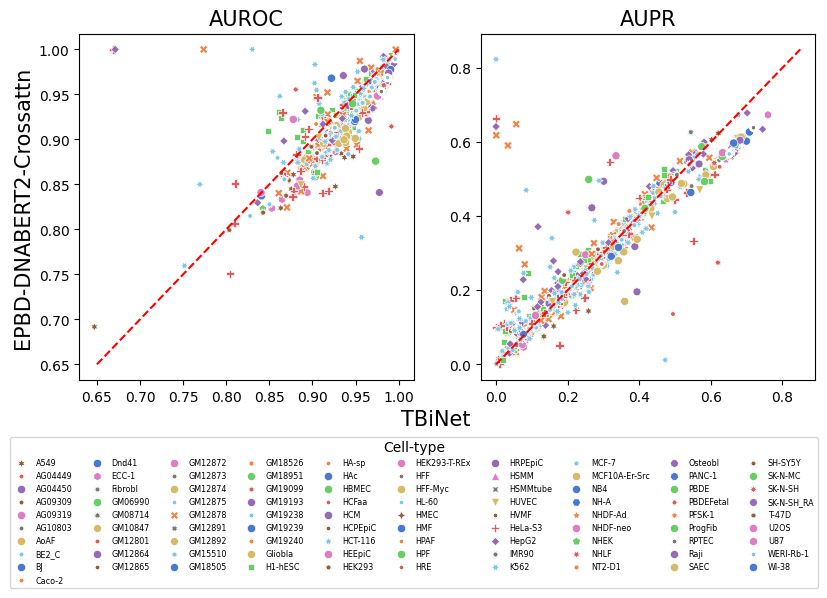

In [41]:
# not completed yet
model_name = "dnabert2_epbd_crossattn_bestmodel"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.5))

sns.scatterplot(x=result_df["tbinet_auroc"], y=result_df[f"{model_name}_auroc"], ax=ax1, hue=result_df["cell"], style=result_df["cell"], palette="muted")
ax1.plot([.65,1], [.65, 1], color="r", linestyle='--')
ax1.legend().remove()
ax1.set_ylabel("EPBD-DNABERT2-Crossattn", fontsize=15)
ax1.set_xlabel("")#"DNABERT2")
ax1.set_title("AUROC", fontsize=15)

sns.scatterplot(x=result_df["tbinet_aupr"], y=result_df[f"{model_name}_aupr"], ax=ax2, hue=result_df["cell"], style=result_df["cell"], palette="muted")
ax2.plot([0, .85], [0, .85], color="r", linestyle='--')
ax2.set_ylabel("")
ax2.set_xlabel("")#"DNABERT2")
ax2.set_title("AUPR", fontsize=15)

fig.text(0.5, 0.01, 'TBiNet', ha='center', fontsize=15)

handles, labels = ax2.get_legend_handles_labels()
# sort both labels and handles by labels
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
ax2.legend(handles, labels, bbox_to_anchor=(-.2, -.6), loc='lower center', borderaxespad=0, fontsize="xx-small", title="Cell-type", ncols=10)

plt.savefig(f"data/figures/tbinet_vs_dnabert2_epbd_crossattn_auroc_aupr_celltypes.png", dpi=300, format="png", bbox_inches='tight', pad_inches=.05)
plt.show()